<a href="https://colab.research.google.com/github/lmf55/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/Atividade%20Aula%203.4/Atividade_Aula_3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.90MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[-0.1578, -0.1619,  0.0484, -0.2144, -0.8057, -0.4516, -0.5437,  0.0920,
         -0.1660, -0.1250]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [7]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [8]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train()
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Print no final de cada mini-batch
        print(f'Época: {epoch+1}/{n_epochs}, batch: {i+1}/{len(loader_train)}, loss: {loss.item():.4f}')

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval()
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad():
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()

            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(
        f'Fim da época [{epoch+1}/{n_epochs}], '
        f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, '
        f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Época: 1/5, batch: 1/480, loss: 2.2681
Época: 1/5, batch: 2/480, loss: 1.8613
Época: 1/5, batch: 3/480, loss: 1.8198
Época: 1/5, batch: 4/480, loss: 1.7808
Época: 1/5, batch: 5/480, loss: 1.3643
Época: 1/5, batch: 6/480, loss: 1.0576
Época: 1/5, batch: 7/480, loss: 1.0455
Época: 1/5, batch: 8/480, loss: 1.0055
Época: 1/5, batch: 9/480, loss: 0.9148
Época: 1/5, batch: 10/480, loss: 0.8506
Época: 1/5, batch: 11/480, loss: 0.7562
Época: 1/5, batch: 12/480, loss: 0.8621
Época: 1/5, batch: 13/480, loss: 0.8603
Época: 1/5, batch: 14/480, loss: 0.7038
Época: 1/5, batch: 15/480, loss: 0.6254
Época: 1/5, batch: 16/480, loss: 0.6871
Época: 1/5, batch: 17/480, loss: 0.7077
Época: 1/5, batch: 18/480, loss: 0.5719
Época: 1/5, batch: 19/480, loss: 0.5913
Época: 1/5, batch: 20/480, loss: 0.6247
Época: 1/5, batch: 21/480, loss: 0.5434
Época: 1/5, batch: 22/480, loss: 0.6487
Época: 1/5, batch: 23/480, loss: 0.8745
Época: 1/5, batch: 24/480, loss: 0.4461
Época: 1/5, batch: 25/480, loss: 0.5919
Época: 1/

In [9]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2803
Última acurácia de treinamento: 0.9206
Última perda de validação: 0.3069
Última acurácia de validação: 0.9149


### Visualizando a evolução da perda e acurácia

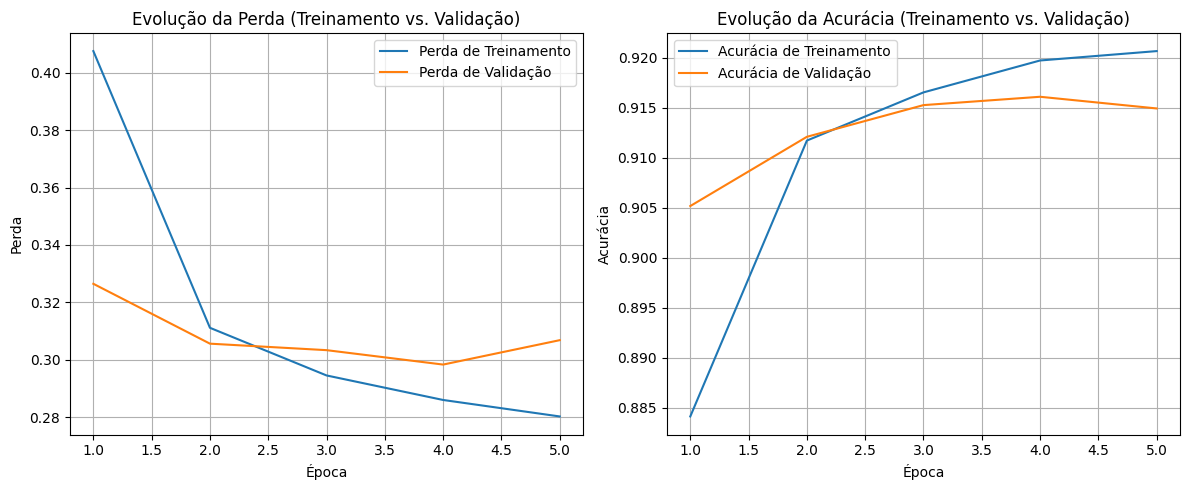

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

In [12]:
def treinar_com_batch_size(batch_size_experimento, n_epochs_experimento=3, learning_rate=0.5):

    loader_train_exp = DataLoader(
        dataset_train,
        batch_size=batch_size_experimento,
        shuffle=True
    )

    model_exp = torch.nn.Linear(28*28, 10)
    criterion_exp = torch.nn.CrossEntropyLoss()
    optimizer_exp = torch.optim.SGD(model_exp.parameters(), lr=learning_rate)

    losses = []
    x_axis = []

    for epoch in range(n_epochs_experimento):
        model_exp.train()

        for batch_idx, (x_batch, y_batch) in enumerate(loader_train_exp):
            inputs = x_batch.view(-1, 28*28)
            labels = y_batch

            outputs = model_exp(inputs)
            loss = criterion_exp(outputs, labels)

            optimizer_exp.zero_grad()
            loss.backward()
            optimizer_exp.step()

            losses.append(loss.item())

            # posição fracionária da época
            progresso_epoca = epoch + (batch_idx + 1) / len(loader_train_exp)
            x_axis.append(progresso_epoca)

    return x_axis, losses

In [13]:
batch_sizes = [50, 100, 200, 500]

resultados = {}

for bs in batch_sizes:
    print(f'Treinando com batch_size = {bs}')
    x_axis, losses = treinar_com_batch_size(bs, n_epochs_experimento=3, learning_rate=0.5)
    resultados[bs] = (x_axis, losses)

Treinando com batch_size = 50
Treinando com batch_size = 100
Treinando com batch_size = 200
Treinando com batch_size = 500


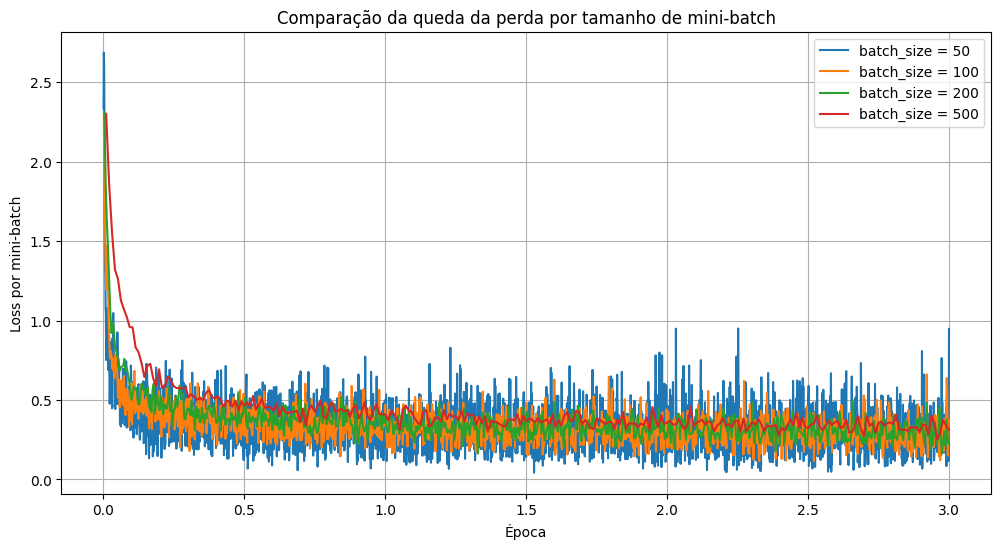

In [14]:
plt.figure(figsize=(12, 6))

for bs in batch_sizes:
    x_axis, losses = resultados[bs]
    plt.plot(x_axis, losses, label=f'batch_size = {bs}')

plt.xlabel('Época')
plt.ylabel('Loss por mini-batch')
plt.title('Comparação da queda da perda por tamanho de mini-batch')
plt.legend()
plt.grid(True)
plt.show()

Ao comparar diferentes tamanhos de mini-batch, é possível observar que batches menores atualizam os pesos com mais frequência dentro de uma época.

Isso pode fazer a perda variar mais, pois cada atualização usa uma amostra menor dos dados.

Batches maiores tendem a gerar uma curva de perda mais estável, porém fazem menos atualizações por época.

Dessa forma, existe um equilíbrio: mini-batches pequenos podem aprender mais rapidamente, mas com mais oscilação; mini-batches grandes são mais estáveis, mas podem atualizar os pesos com menor frequência.

# Atividades

## Perguntas

**1. Qual é o tamanho do mini-batch?**
O tamanho do mini-batch é 100, pois o notebook define batch_size = 100.
Isso significa que o modelo processa 100 imagens por vez antes de atualizar os pesos.

**2. Em uma época, quantos mini-batches existem?**
No notebook atual, o dataset de treino possui 48.000 amostras, pois 80% das 60.000 imagens do MNIST foram usadas para treino.
Como batch_size = 100: 48.000 / 100 = 480 mini-batches de treinamento por época.
O dataset de validação possui 12.000 amostras: 12.000 / 100 = 120 mini-batches de validação.

**3. Qual é a definição de época?**
Uma época é uma passagem completa por todo o conjunto de treinamento.
Neste caso, uma época termina quando todos os 480 mini-batches de treino foram processados uma vez.

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

## Conclusões sobre os experimentos deste notebook


Nesta atividade, foi possível entender o funcionamento do gradiente descendente estocástico por mini-batches.

O mini-batch define quantas amostras são usadas antes de cada atualização dos pesos.
No notebook inicial, foi usado batch_size = 100, o que gerou 480 mini-batches de treino por época, considerando a divisão de 48.000 amostras para treinamento.

Uma época corresponde a uma passagem completa por todo o conjunto de treinamento.
Também foi possível observar que o tamanho do mini-batch influencia o comportamento da curva de perda. Mini-batches menores tendem a gerar mais oscilações, enquanto mini-batches maiores tendem a produzir uma curva mais estável.

Essa análise ajuda a compreender por que o batch_size é um hiperparâmetro importante no treinamento de redes neurais.